In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import timedelta

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Data preprocessing

In [3]:
data_path = "data/compas-scores-two-years.csv"
df  = pd.read_csv(data_path)

In [3]:
#Columns 
NUMERICAL_FEATURES = [
                      'age', 
                      'juv_fel_count', 
                      'juv_misd_count', 
                      'juv_other_count', 
                      'priors_count', 
                      'jail_duration', 
                      'time_btw_offense_and_jail'
                      ]

CATEGORICAL_FEATURES = [
                        'sex_Female', 
                        'sex_Male',
                        'c_charge_degree_F', 
                        'c_charge_degree_M', 
                        'race_African-American',
                        'race_Asian', 
                        'race_Caucasian', 
                        'race_Hispanic', 
                        'race_Native American',
                        'race_Other'
                        ]

TARGET = 'is_recid'

In [4]:
#DATA PREPROCESSING 

class DataPreprocessor:
    def __init__(self, raw_df : pd.DataFrame):
        self.raw_df = raw_df
        self.selected_cols = ['sex', 'age', 'race', 'juv_fel_count',
        'juv_misd_count', 'juv_other_count', 'priors_count', 'c_jail_in', 
        'c_jail_out','c_charge_degree', 'is_recid', 'c_offense_date']


    def preprocess(self) -> (pd.DataFrame, pd.DataFrame, pd.DataFrame):
        silver_df = self.raw2silver(self.raw_df)
        gold_df = self.silver2gold(silver_df)
        mlready_dfs = self.gold2ml(gold_df)
        return mlready_dfs, gold_df #send gold to compute metrics 
    
    def raw2silver(self, raw_df : pd.DataFrame) -> pd.DataFrame:
        silver_df = raw_df
        silver_df = silver_df[self.selected_cols]
        return silver_df

    def silver2gold(self, silver_df : pd.DataFrame) -> pd.DataFrame:
        gold_df = silver_df
        gold_df = self._create_gold_features(gold_df)
        gold_df = self._filter_data(gold_df)

        return gold_df
    
    def gold2ml(self, gold_df : pd.DataFrame) -> pd.DataFrame: 
        mlready_df = gold_df
        #Dummify
        mlready_df = pd.get_dummies(mlready_df, columns=["sex", "c_charge_degree", "race"])
        return mlready_df

    def _create_gold_features(self,gold_df : pd.DataFrame) -> pd.DataFrame : 
        gold_df['jail_duration'] = (pd.to_datetime(gold_df['c_jail_out']) - pd.to_datetime(gold_df['c_jail_in'])) / pd.Timedelta(days=1)
        gold_df['time_btw_offense_and_jail'] = (pd.to_datetime(gold_df['c_jail_in']) - pd.to_datetime(gold_df['c_offense_date']))/ pd.Timedelta(days=1)
        return gold_df

    def _filter_data(self, gold_df : pd.DataFrame) -> pd.DataFrame:
        gold_df = gold_df[gold_df['jail_duration'] >= 0]
        gold_df = gold_df[gold_df['time_btw_offense_and_jail'] >= 0]
        gold_df = gold_df.drop(columns=['c_jail_in', 'c_jail_out', 'c_offense_date'])
        return gold_df

In [5]:
data_preprocessor = DataPreprocessor(df)
mlready_df, gold_df = data_preprocessor.preprocess()

/var/folders/vs/2dbt92n96_13g_jl9jw_sd8m0000gn/T/ipykernel_6456/2506570328.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_df['jail_duration'] = (pd.to_datetime(gold_df['c_jail_out']) - pd.to_datetime(gold_df['c_jail_in'])) / pd.Timedelta(days=1)
/var/folders/vs/2dbt92n96_13g_jl9jw_sd8m0000gn/T/ipykernel_6456/2506570328.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_df['time_btw_offense_and_jail'] = (pd.to_datetime(gold_df['c_jail_in']) - pd.to_datetime(gold_df['c_offense_date']))/ pd.T

## Stats

In [6]:
def compute_metrics(df, model_prediction = None): 
    """
    Compute and print recidivism rates by race, age category, and sex, and optionally compare with model predictions.
    Args:       
        - df (pd.DataFrame): The input DataFrame containing the data.
        - model_prediction (str, optional): The column name of the model's predictions to compare against. Defaults to None.
    Returns:        
        None: Prints the computed metrics to the console.
    """

    metrics_ethnic = df.groupby('race').agg({'is_recid':['sum', 'count']})
    metrics_ethnic['Rate'] = round(100 * metrics_ethnic[('is_recid', 'sum')] / metrics_ethnic[('is_recid', 'count')], 2)
    metrics_ethnic['Recid'] = metrics_ethnic[('is_recid', 'sum')]
    metrics_ethnic['Total'] = metrics_ethnic[('is_recid', 'count')]
    metrics_ethnic = metrics_ethnic[['Recid', 'Total', 'Rate']]

    if model_prediction is not None:
        metrics_ethnic_pred = df.groupby('race').agg({model_prediction:['sum', 'count']})
        metrics_ethnic_pred['Model_Rate'] = round(100 * metrics_ethnic_pred[(model_prediction, 'sum')] / metrics_ethnic_pred[(model_prediction, 'count')], 2)
        metrics_ethnic_pred['Model_Recid'] = metrics_ethnic_pred[(model_prediction, 'sum')]
        metrics_ethnic = metrics_ethnic.join(metrics_ethnic_pred, how='inner', on = 'race')
        metrics_ethnic = metrics_ethnic[['Recid', 'Model_Recid', 'Total', 'Rate', 'Model_Rate']]

    metrics_ethnic = metrics_ethnic.sort_values(by='Rate', ascending=False)
    print(metrics_ethnic, "\n")

    df['age_category'] = df['age'].apply(lambda x: '18-25' if 18 <= x <= 25 else ('26-45' if 26 <= x <= 45 else ('46-65' if 46 <= x <= 65 else '66+')))

    metrics_age = df.groupby('age_category').agg({'is_recid':['sum', 'count']})
    metrics_age['Rate'] = round(100 * metrics_age[('is_recid', 'sum')] / metrics_age[('is_recid', 'count')], 2)
    metrics_age['Recid'] = metrics_age[('is_recid', 'sum')]
    metrics_age['Total'] = metrics_age[('is_recid', 'count')]
    metrics_age = metrics_age[['Recid', 'Total', 'Rate']]

    if model_prediction is not None:
        metrics_age_pred = df.groupby('age_category').agg({model_prediction:['sum', 'count']})
        metrics_age_pred['Model_Rate'] = round(100 * metrics_age_pred[(model_prediction, 'sum')] / metrics_age_pred[(model_prediction, 'count')], 2)
        metrics_age_pred['Model_Recid'] = metrics_age_pred[(model_prediction, 'sum')]
        metrics_age = metrics_age.join(metrics_age_pred, how='inner', on = 'age_category')
        metrics_age = metrics_age[['Recid', 'Model_Recid', 'Total', 'Rate', 'Model_Rate']]

    metrics_age = metrics_age.sort_values(by='Rate', ascending=False)
    print(metrics_age, "\n")

    metrics_sex = df.groupby('sex').agg({'is_recid':['sum', 'count']})
    metrics_sex['Rate'] = round(100 * metrics_sex[('is_recid', 'sum')] / metrics_sex[('is_recid', 'count')], 2)
    metrics_sex['Recid'] = metrics_sex[('is_recid', 'sum')]
    metrics_sex['Total'] = metrics_sex[('is_recid', 'count')]
    metrics_sex = metrics_sex[['Recid', 'Total', 'Rate']]

    if model_prediction is not None:
        metrics_sex_pred = df.groupby('sex').agg({model_prediction:['sum', 'count']})
        metrics_sex_pred['Model_Rate'] = round(100 * metrics_sex_pred[(model_prediction, 'sum')] / metrics_sex_pred[(model_prediction, 'count')], 2)
        metrics_sex_pred['Model_Recid'] = metrics_sex_pred[(model_prediction, 'sum')]
        metrics_sex = metrics_sex.join(metrics_sex_pred, how='inner', on = 'sex')
        metrics_sex = metrics_sex[['Recid', 'Model_Recid', 'Total', 'Rate', 'Model_Rate']]

    metrics_sex = metrics_sex.sort_values(by='Rate', ascending=False)
    print(metrics_sex)

    return metrics_ethnic, metrics_age, metrics_sex

In [7]:
compute_metrics(gold_df)

                 Recid Total   Rate
                                   
race                               
African-American  1621  2826  57.36
Native American      8    14  57.14
Caucasian          828  1969  42.05
Other              119   304  39.14
Hispanic           186   485  38.35
Asian                8    28  28.57 

             Recid Total   Rate
                               
age_category                   
18-25          872  1487  58.64
26-45         1497  3025  49.49
46-65          381  1036  36.78
66+             20    78  25.64 

       Recid Total   Rate
                         
sex                      
Male    2345  4527  51.80
Female   425  1099  38.67


(                 Recid Total   Rate
                                    
 race                               
 African-American  1621  2826  57.36
 Native American      8    14  57.14
 Caucasian          828  1969  42.05
 Other              119   304  39.14
 Hispanic           186   485  38.35
 Asian                8    28  28.57,
              Recid Total   Rate
                                
 age_category                   
 18-25          872  1487  58.64
 26-45         1497  3025  49.49
 46-65          381  1036  36.78
 66+             20    78  25.64,
        Recid Total   Rate
                          
 sex                      
 Male    2345  4527  51.80
 Female   425  1099  38.67)

# Training model with race, sex, age features

In [8]:
#Split into train and test
mlready_train_df, ml_ready_test_df = train_test_split(mlready_df, test_size=0.5, random_state=1234)

#Normalize features
scaler = StandardScaler()
mlready_train_df[NUMERICAL_FEATURES] = scaler.fit_transform(mlready_train_df[NUMERICAL_FEATURES])
ml_ready_test_df[NUMERICAL_FEATURES] = scaler.transform(ml_ready_test_df[NUMERICAL_FEATURES])

In [ ]:
#X,y for train and test
X_train = mlready_train_df.drop(columns=[TARGET])
y_train = mlready_train_df[TARGET]

X_test = ml_ready_test_df.drop(columns=[TARGET])
y_test = ml_ready_test_df[TARGET]

In [10]:
#Hyperparameter tuning for Logistic Regression
param_grid_logreg = {
    'C': [0.01, 0.1, 0.25, 0.5, 1, 2, 4, 10]
}

grid_logreg = GridSearchCV(LogisticRegression(), param_grid_logreg, cv=5, scoring='f1')
grid_logreg.fit(X_train, y_train)
print(f"best parameter Logistic Regression : {grid_logreg.best_params_}")

best parameter Logistic Regression : {'C': 10}


In [30]:
#Logistic regression
logistic_model = LogisticRegression(C = 0.25, max_iter=1000)
logistic_model.fit(X_train, y_train)
y_hat_logreg = logistic_model.predict(X_test)
proba_logreg = logistic_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_hat_logreg))

              precision    recall  f1-score   support

           0       0.65      0.75      0.70      1417
           1       0.70      0.59      0.64      1396

    accuracy                           0.67      2813
   macro avg       0.68      0.67      0.67      2813
weighted avg       0.68      0.67      0.67      2813



In [12]:
#Hyperparameter tuning for XGBoost
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.005],
    'n_estimators': [50, 80, 100, 500]
}

grid_xgb = GridSearchCV(XGBClassifier(), param_grid_xgb, cv=5, scoring='f1')
grid_xgb.fit(X_train, y_train)
print(f"best parameters XGB : {grid_xgb.best_params_}")

best parameters XGB : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [29]:
#XGBoost
xgb_classifier = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_classifier.fit(X_train, y_train) 
y_hat_xgb = xgb_classifier.predict(X_test)
proba_xgb = xgb_classifier.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_hat_xgb))

              precision    recall  f1-score   support

           0       0.68      0.75      0.71      1417
           1       0.71      0.64      0.68      1396

    accuracy                           0.69      2813
   macro avg       0.70      0.69      0.69      2813
weighted avg       0.70      0.69      0.69      2813



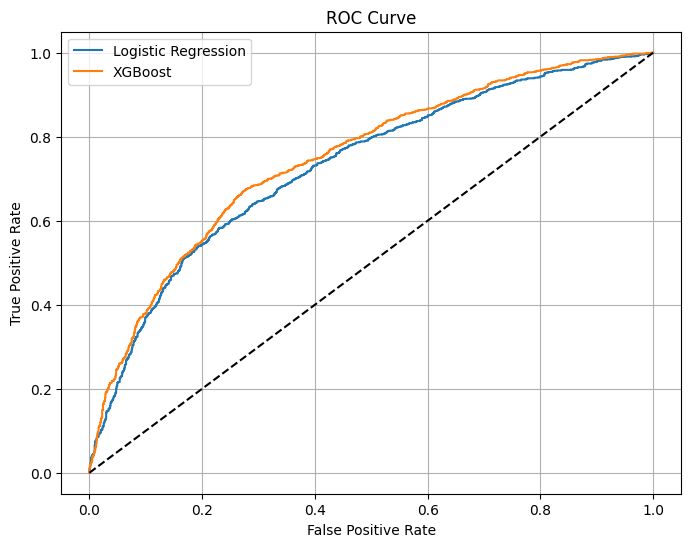

In [14]:
logreg_roc = roc_curve(y_test, proba_logreg)
xgb_roc = roc_curve(y_test, proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(logreg_roc[0], logreg_roc[1], label='Logistic Regression')
plt.plot(xgb_roc[0], xgb_roc[1], label='XGBoost')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid()
plt.legend()
plt.show()


## Stats model 

In [15]:
def undummify(df):
    analysis_df = df.copy()
    
    groups = {
        'sex': [c for c in df.columns if c.startswith('sex_')],
        'race': [c for c in df.columns if c.startswith('race_')],
        'c_charge_degree': [c for c in df.columns if c.startswith('c_charge_degree_')]
    }

    for target_col, dummy_cols in groups.items():
        analysis_df[target_col] = (analysis_df[dummy_cols]
                                   .idxmax(axis=1)
                                   .str.replace(f"{target_col}_", ""))

        analysis_df = analysis_df.drop(columns=dummy_cols)
    return analysis_df

test_set = undummify(ml_ready_test_df)
test_set[NUMERICAL_FEATURES] = scaler.inverse_transform(test_set[NUMERICAL_FEATURES])

In [16]:
compute_metrics(test_set)

                 Recid Total   Rate
                                   
race                               
Native American      3     5  60.00
African-American   806  1401  57.53
Caucasian          427   995  42.91
Other               60   147  40.82
Hispanic            96   250  38.40
Asian                4    15  26.67 

             Recid Total   Rate
                               
age_category                   
18-25          446   754  59.15
26-45          743  1494  49.73
46-65          195   521  37.43
66+             12    44  27.27 

       Recid Total   Rate
                         
sex                      
Male    1185  2263  52.36
Female   211   550  38.36


(                 Recid Total   Rate
                                    
 race                               
 Native American      3     5  60.00
 African-American   806  1401  57.53
 Caucasian          427   995  42.91
 Other               60   147  40.82
 Hispanic            96   250  38.40
 Asian                4    15  26.67,
              Recid Total   Rate
                                
 age_category                   
 18-25          446   754  59.15
 26-45          743  1494  49.73
 46-65          195   521  37.43
 66+             12    44  27.27,
        Recid Total   Rate
                          
 sex                      
 Male    1185  2263  52.36
 Female   211   550  38.36)

In [17]:
test_set['logistic_pred'] = y_hat_logreg
metrics_logreg = compute_metrics(test_set, model_prediction='logistic_pred')

                 Recid Model_Recid Total   Rate Model_Rate
                                                          
race                                                      
Native American      3           2     5  60.00      40.00
African-American   806         847  1401  57.53      60.46
Caucasian          427         259   995  42.91      26.03
Other               60          23   147  40.82      15.65
Hispanic            96          47   250  38.40      18.80
Asian                4           3    15  26.67      20.00 

             Recid Model_Recid Total   Rate Model_Rate
                                                      
age_category                                          
18-25          446         483   754  59.15      64.06
26-45          743         616  1494  49.73      41.23
46-65          195          82   521  37.43      15.74
66+             12           0    44  27.27       0.00 

       Recid Model_Recid Total   Rate Model_Rate
                               

In [18]:
test_set['xgboost_pred'] = y_hat_xgb
metrics_xgb = compute_metrics(test_set, model_prediction='xgboost_pred')

                 Recid Model_Recid Total   Rate Model_Rate
                                                          
race                                                      
Native American      3           3     5  60.00      60.00
African-American   806         830  1401  57.53      59.24
Caucasian          427         308   995  42.91      30.95
Other               60          42   147  40.82      28.57
Hispanic            96          70   250  38.40      28.00
Asian                4           3    15  26.67      20.00 

             Recid Model_Recid Total   Rate Model_Rate
                                                      
age_category                                          
18-25          446         447   754  59.15      59.28
26-45          743         672  1494  49.73      44.98
46-65          195         134   521  37.43      25.72
66+             12           3    44  27.27       6.82 

       Recid Model_Recid Total   Rate Model_Rate
                               

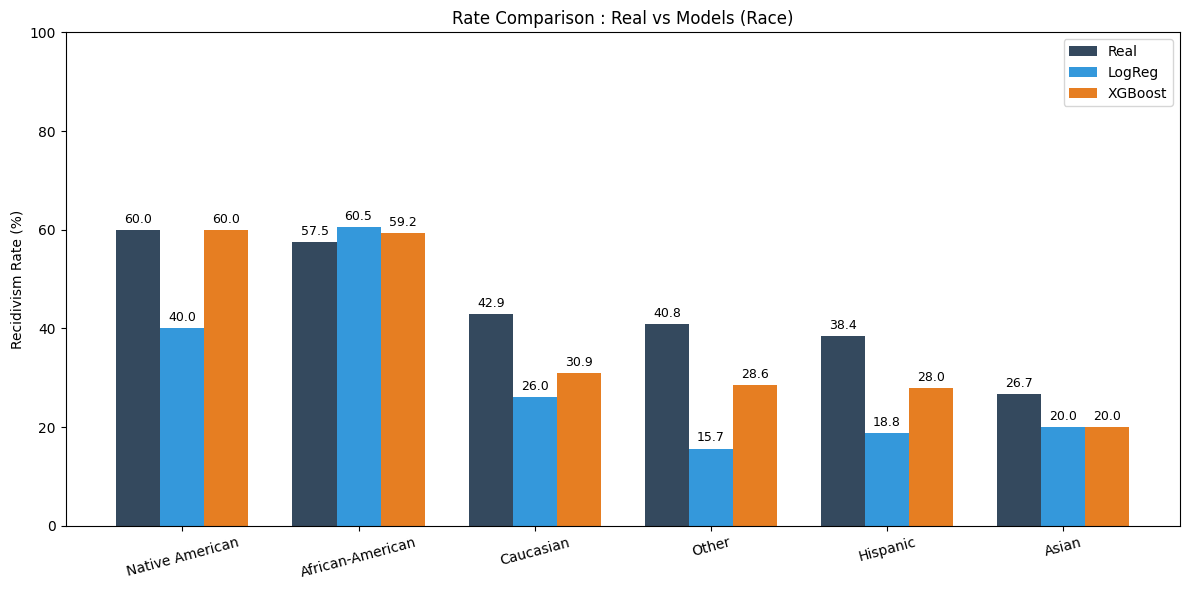

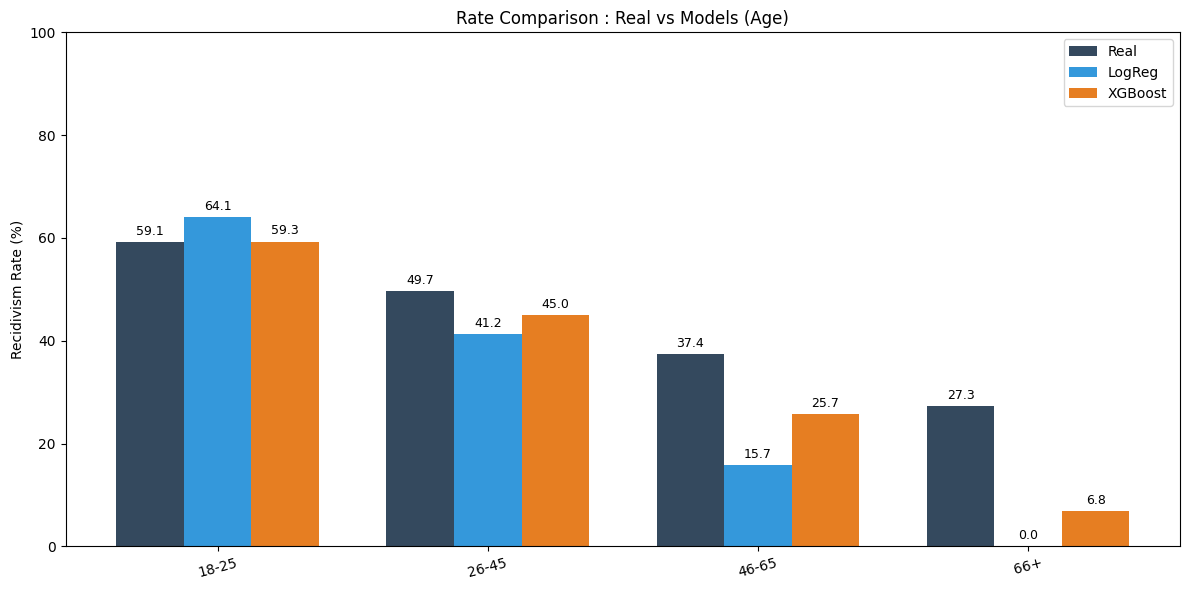

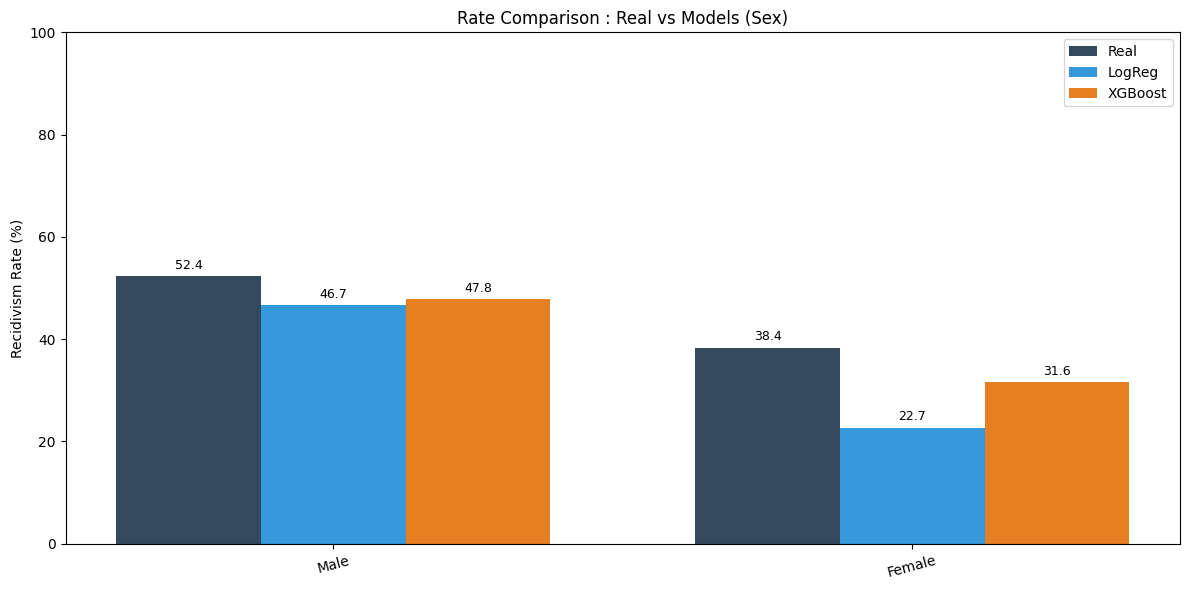

In [19]:
def plot_model_comparison(metrics_logreg, metrics_xgb, title_suffix=""):
    """
    Generate comparative bar plots from the metrics DataFrames.
    """
    # Data extraction
    labels = metrics_logreg.index
    real_rate = metrics_logreg['Rate']
    logreg_rate = metrics_logreg['Model_Rate']
    xgb_rate = metrics_xgb['Model_Rate']
    
    x = np.arange(len(labels))  
    width = 0.25               
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Barplots creation
    rects1 = ax.bar(x - width, real_rate, width, label='Real', color='#34495e')
    rects2 = ax.bar(x, logreg_rate, width, label='LogReg', color='#3498db')
    rects3 = ax.bar(x + width, xgb_rate, width, label='XGBoost', color='#e67e22')
    
    # Titles and labels
    ax.set_ylabel('Recidivism Rate (%)')
    ax.set_title(f'Rate Comparison : Real vs Models ({title_suffix})')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.legend()
    ax.set_ylim(0, 100) 
    
    # Adding value labels on top of the bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)
    
    plt.tight_layout()
    plt.show()


# Race
plot_model_comparison(metrics_logreg[0], 
                      metrics_xgb[0], 
                      title_suffix="Race")

# Age
plot_model_comparison(metrics_logreg[1], 
                      metrics_xgb[1], 
                      title_suffix="Age")

# Sex
plot_model_comparison(metrics_logreg[2],
                      metrics_xgb[2],
                      title_suffix="Sex")   

# Training without race feature

In [20]:
ml_ready_train_df_no_race = mlready_train_df.drop(columns=[col for col in mlready_train_df.columns if col.startswith('race_')])
ml_ready_test_df_no_race = ml_ready_test_df.drop(columns=[col for col in ml_ready_test_df.columns if col.startswith('race_')])

# Features for train and test without race
X_train_no_race = ml_ready_train_df_no_race.drop(columns=[TARGET])
X_test_no_race = ml_ready_test_df_no_race.drop(columns=[TARGET])

In [ ]:
#Logistic regression no race features
logistic_model_no_race = LogisticRegression(C = 0.25, max_iter=1000)
logistic_model_no_race.fit(X_train_no_race, y_train)
y_hat_logreg_no_race = logistic_model_no_race.predict(X_test_no_race)
proba_logreg_no_race = logistic_model_no_race.predict_proba(X_test_no_race)[:, 1]
print(classification_report(y_test, y_hat_logreg_no_race))

              precision    recall  f1-score   support

           0       0.66      0.77      0.71      1417
           1       0.72      0.60      0.65      1396

    accuracy                           0.68      2813
   macro avg       0.69      0.68      0.68      2813
weighted avg       0.69      0.68      0.68      2813



In [ ]:
#XGBoost no race features
xgb_classifier_no_race = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_classifier_no_race.fit(X_train_no_race, y_train)
y_hat_xgb_no_race = xgb_classifier_no_race.predict(X_test_no_race)
proba_xgb_no_race = xgb_classifier_no_race.predict_proba(X_test_no_race)[:, 1]
print(classification_report(y_test, y_hat_xgb_no_race))

              precision    recall  f1-score   support

           0       0.69      0.76      0.72      1417
           1       0.72      0.65      0.68      1396

    accuracy                           0.70      2813
   macro avg       0.70      0.70      0.70      2813
weighted avg       0.70      0.70      0.70      2813



In [23]:
test_set['logistic_no_race_pred'] = y_hat_logreg_no_race
metrics_logreg_no_race = compute_metrics(test_set, model_prediction='logistic_no_race_pred')

                 Recid Model_Recid Total   Rate Model_Rate
                                                          
race                                                      
Native American      3           3     5  60.00      60.00
African-American   806         745  1401  57.53      53.18
Caucasian          427         295   995  42.91      29.65
Other               60          46   147  40.82      31.29
Hispanic            96          73   250  38.40      29.20
Asian                4           3    15  26.67      20.00 

             Recid Model_Recid Total   Rate Model_Rate
                                                      
age_category                                          
18-25          446         474   754  59.15      62.86
26-45          743         609  1494  49.73      40.76
46-65          195          82   521  37.43      15.74
66+             12           0    44  27.27       0.00 

       Recid Model_Recid Total   Rate Model_Rate
                               

In [24]:
test_set['xgboost_no_race_pred'] = y_hat_xgb_no_race
metrics_xgb_no_race = compute_metrics(test_set, model_prediction='xgboost_no_race_pred')

                 Recid Model_Recid Total   Rate Model_Rate
                                                          
race                                                      
Native American      3           3     5  60.00      60.00
African-American   806         784  1401  57.53      55.96
Caucasian          427         335   995  42.91      33.67
Other               60          48   147  40.82      32.65
Hispanic            96          76   250  38.40      30.40
Asian                4           4    15  26.67      26.67 

             Recid Model_Recid Total   Rate Model_Rate
                                                      
age_category                                          
18-25          446         448   754  59.15      59.42
26-45          743         655  1494  49.73      43.84
46-65          195         144   521  37.43      27.64
66+             12           3    44  27.27       6.82 

       Recid Model_Recid Total   Rate Model_Rate
                               

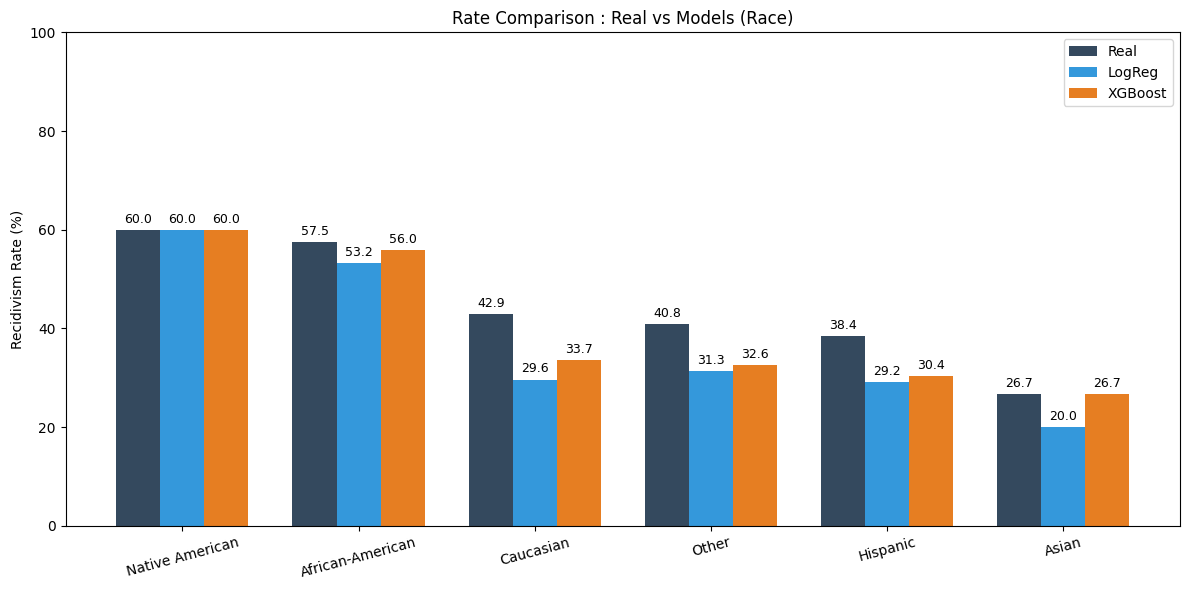

In [25]:
# Race
plot_model_comparison(metrics_logreg_no_race[0], 
                      metrics_xgb_no_race[0], 
                      title_suffix="Race")

# Feature Importance 

Considering again the model with all the features, let's see the feature importance for each model.

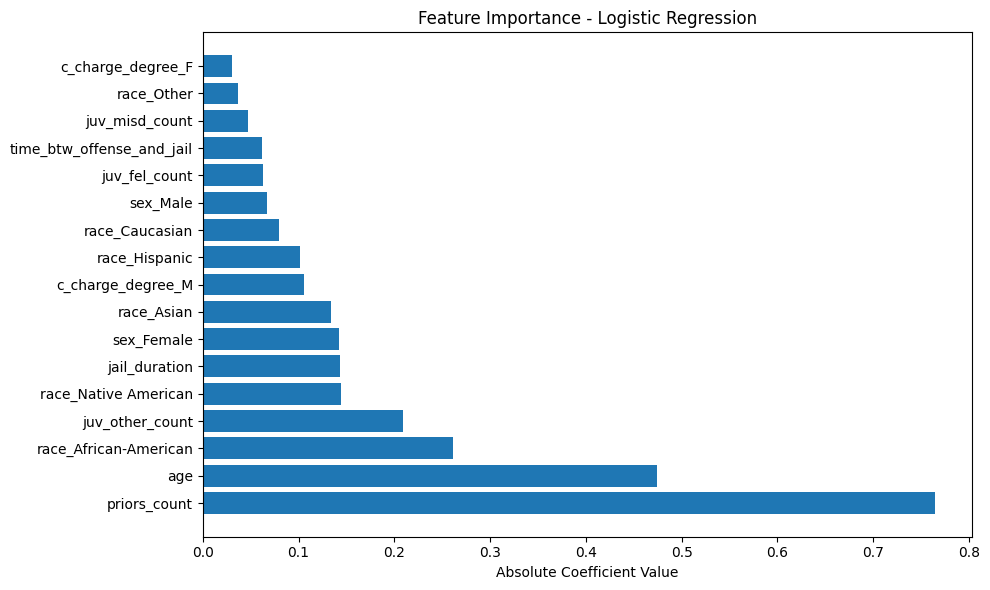

Logistic Regression Feature Importance:
                      Feature  Coefficient
4                priors_count     0.764776
0                         age     0.474548
11      race_African-American     0.261278
3             juv_other_count     0.209170
15       race_Native American     0.144448
5               jail_duration     0.142703
7                  sex_Female     0.142393
12                 race_Asian     0.133724
10          c_charge_degree_M     0.105948
14              race_Hispanic     0.101075
13             race_Caucasian     0.079948
8                    sex_Male     0.067262
1               juv_fel_count     0.062500
6   time_btw_offense_and_jail     0.061836
2              juv_misd_count     0.046656
16                 race_Other     0.037110
9           c_charge_degree_F     0.030817



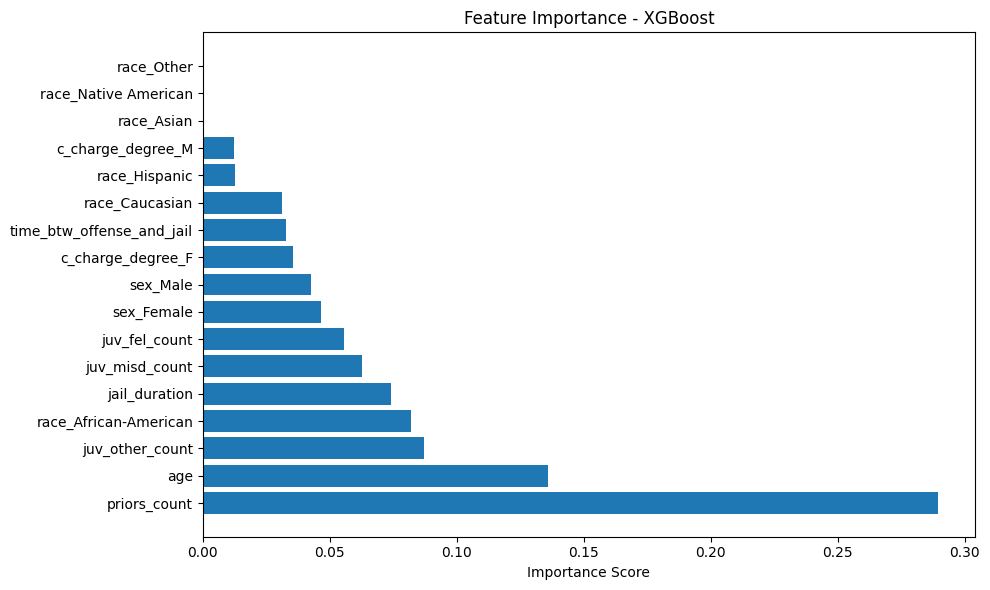

XGBoost Feature Importance:
                      Feature  Importance
4                priors_count    0.289491
0                         age    0.136044
3             juv_other_count    0.087114
11      race_African-American    0.081972
5               jail_duration    0.073972
2              juv_misd_count    0.062472
1               juv_fel_count    0.055444
7                  sex_Female    0.046667
8                    sex_Male    0.042517
9           c_charge_degree_F    0.035558
6   time_btw_offense_and_jail    0.032812
13             race_Caucasian    0.031029
14              race_Hispanic    0.012749
10          c_charge_degree_M    0.012159
12                 race_Asian    0.000000
15       race_Native American    0.000000
16                 race_Other    0.000000


In [31]:
# Logistic Regression Feature Importance (from coefficients)
logreg_coef = logistic_model.coef_[0]
feature_names = X_train.columns
feature_importance_logreg = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': np.abs(logreg_coef)
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_logreg['Feature'], feature_importance_logreg['Coefficient'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importance - Logistic Regression')
plt.tight_layout()
plt.show()
print("Logistic Regression Feature Importance:")
print(feature_importance_logreg)
print()

# XGBoost Feature Importance
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_xgb['Feature'], feature_importance_xgb['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()
print("XGBoost Feature Importance:")
print(feature_importance_xgb)